In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

In [2]:
def Segment_Nuclei_Watershed(image,
                             dapi_threshold=30):

    blue = image[:,:,2]

    _, binary = cv2.threshold(
        blue,
        dapi_threshold,
        255,
        cv2.THRESH_BINARY
    )

    kernel = np.ones((3,3), np.uint8)

    opening = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        kernel,
        iterations=1
    )

    dist = cv2.distanceTransform(
        opening,
        cv2.DIST_L2,
        5
    )

    _, sure_fg = cv2.threshold(
        dist,
        0.3*dist.max(),
        255,
        0
    )

    sure_fg = np.uint8(sure_fg)

    num_labels, markers = cv2.connectedComponents(
        sure_fg
    )

    markers = markers + 1

    unknown = cv2.subtract(
        opening,
        sure_fg
    )

    markers[unknown == 255] = 0

    rgb = image.copy()

    markers = cv2.watershed(
        cv2.cvtColor(
            rgb,
            cv2.COLOR_RGB2BGR
        ),
        markers
    )

    return markers

In [3]:
def Quantify_Microglia_NFKB(
        image,
        markers,
        nfkb_threshold=60,
        iba1_threshold=40,
        min_nucleus_area=20,
        ring_size=5):

    red = image[:,:,0]
    green = image[:,:,1]

    overlay = image.copy()

    positive_mask = np.zeros(
        image.shape[:2],
        dtype=np.uint8
    )

    positive_nuclei = 0
    total_microglia = 0

    labels = np.unique(markers)

    for label in labels:

        if label <= 1:
            continue

        nucleus_mask = np.zeros(
            image.shape[:2],
            dtype=np.uint8
        )

        nucleus_mask[
            markers == label
        ] = 255

        nucleus_area = np.sum(
            nucleus_mask > 0
        )

        if nucleus_area < min_nucleus_area:
            continue

        # ---------- anillo perinuclear ----------

        kernel = cv2.getStructuringElement(
            cv2.MORPH_ELLIPSE,
            (ring_size, ring_size)
        )

        dilated = cv2.dilate(
            nucleus_mask,
            kernel
        )

        ring = cv2.subtract(
            dilated,
            nucleus_mask
        )

        iba1_pixels = green[
            ring > 0
        ]

        if len(iba1_pixels) == 0:
            continue

        iba1_fraction = np.mean(
            iba1_pixels > iba1_threshold
        )

        # criterio microglía

        if iba1_fraction < 0.20:
            continue

        total_microglia += 1

        # ---------- NFkB nuclear ----------

        nfkb_pixels = red[
            nucleus_mask > 0
        ]

        nfkb_fraction = np.mean(
            nfkb_pixels > nfkb_threshold
        )

        if nfkb_fraction > 0.20:

            positive_nuclei += 1

            positive_mask[
                nucleus_mask > 0
            ] = 255

            contours, _ = cv2.findContours(
                nucleus_mask,
                cv2.RETR_EXTERNAL,
                cv2.CHAIN_APPROX_SIMPLE
            )

            cv2.drawContours(
                overlay,
                contours,
                -1,
                (255,0,0),
                3
            )

    percentage = (
        positive_nuclei /
        total_microglia * 100
        if total_microglia > 0
        else 0
    )

    return (
        total_microglia,
        positive_nuclei,
        percentage,
        overlay,
        positive_mask
    )

In [4]:
path = r"G:\Mi unidad\Doctorado\1 TRATAMIENTOS\FTY720\Inmuno\1D\TRANSVERSAL\NFKB nueva alicuota\LPS F\2 od\3\m all.tif"

output_dir = os.path.dirname(path)

filename = os.path.splitext(
    os.path.basename(path)
)[0]

image = cv2.imread(path)

image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

In [5]:
markers = Segment_Nuclei_Watershed(
    image,
    dapi_threshold=30
)

In [6]:
(
    total_microglia,
    positive_nuclei,
    percentage,
    overlay,
    positive_mask
) = Quantify_Microglia_NFKB(
        image,
        markers,
        nfkb_threshold=40,
        iba1_threshold=40,
        ring_size=25
)

print(
    "Microglial nuclei =",
    total_microglia
)

print(
    "NFkB positive nuclei =",
    positive_nuclei
)

print(
    "Percentage =",
    round(percentage,2),
    "%"
)

Microglial nuclei = 26
NFkB positive nuclei = 20
Percentage = 76.92 %


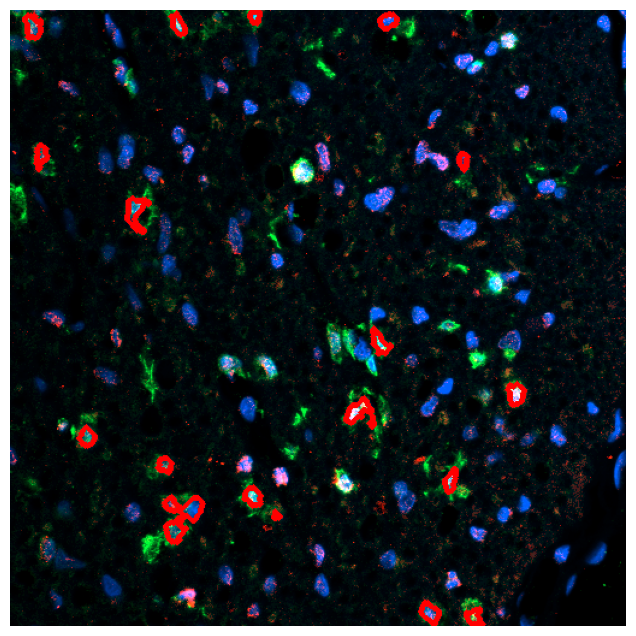

In [7]:
plt.figure(figsize=(8,8))
plt.imshow(overlay)
plt.axis("off")
plt.show()

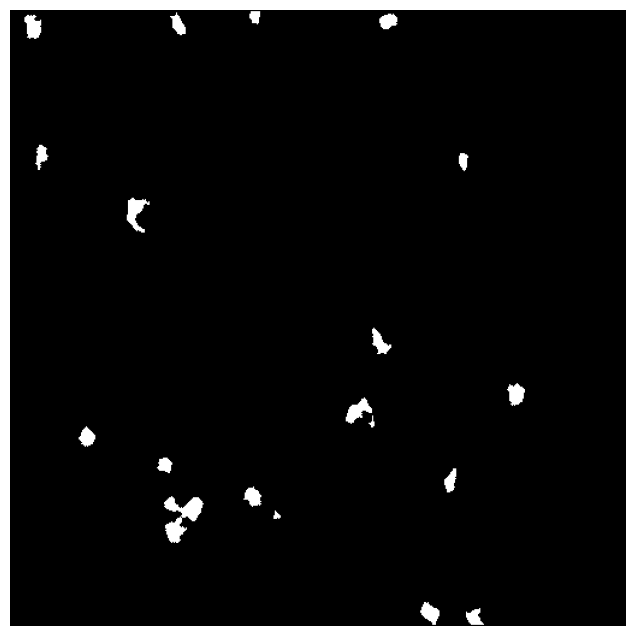

In [8]:
plt.figure(figsize=(8,8))
plt.imshow(
    positive_mask,
    cmap="gray"
)
plt.axis("off")
plt.show()

In [9]:
cv2.imwrite(
    os.path.join(
        output_dir,
        f"{filename}_QC.png"
    ),
    cv2.cvtColor(
        overlay,
        cv2.COLOR_RGB2BGR
    )
)

cv2.imwrite(
    os.path.join(
        output_dir,
        f"{filename}_MASK.png"
    ),
    positive_mask
)

True

In [10]:
cv2.imwrite(
    os.path.join(
        output_dir,
        f"{filename}_QC_IBA1_NFKB.png"
    ),
    cv2.cvtColor(
        overlay,
        cv2.COLOR_RGB2BGR
    )
)

cv2.imwrite(
    os.path.join(
        output_dir,
        f"{filename}_MASK_IBA1_NFKB.png"
    ),
    positive_mask
)

print("Images saved")

Images saved
